In [1]:
#####################################################################################
#################### Loading Julia files needed ##  ###################################
#####################################################################################
################# preamble.jl contains all the packages necessary in this simulation.
include("./mytools/preamble.jl") 
##########################################################################################################################################
######### scenario.jl contains information on TX and RX position,
######### their features (VerticalDipole and GroundSampler respectively),
######### geomagnetic field, altitude, initial and final time, etc. ######################################################################################
include("./mytools/scenario.jl")
import CairoMakie
const CM = CairoMakie
using Optim
using LinearAlgebra  
using Polynomials
using GMT
using Dates
using DSP
#using SavitzkyGolay, Statistics
##################################################################
using Interpolations: interpolate, extrapolate, Gridded, Linear, Line
using SavitzkyGolay
##################################################################
#unique(FIRI.HEADER.f10_7)
#FIRI.HEADER[1960:1980]
#ALT_KM = FIRI.ALTITUDE/1e3

[ Info: Loading CHAOS-7.11.mat


Geodesic Distance from WWVB to PLO: 6568.28 km
Geodesic Distance from WWVB to PIU: 5659.0 km
Geodesic Distance from NAA to PLO: 6568.28 km
Geodesic Distance from NAA to PIU: 5659.0 km
Initial time: 2008-01-10T10:00:00+00:00
Scenario defined.
Datetime range: from 2008-01-10 10:00:00 UTC to 2008-01-11 10:00:00 UTC with a length of 289.


### Funciones necesarias para el análisis

In [2]:
##################################################################

function PlotTrajectories()
    
    output_file = "/home/jp/basefolder_JP/vlf-trajectories"
    lon_min, lon_max = -120, -60  # Ejemplo: América del Norte
    lat_min, lat_max = -10, 50     # Ejemplo: Norteamérica y el Caribe
    # Configuración del gráfico de la costa
    mid_point2 = [sum([lon_min,lon_max])/2, sum([lat_min,lat_max])/2]
    GMT.coast(region=:global, xaxis=(annot=60,), yaxis=(annot=30,), proj=(name=:ortho, center=mid_point), 
    frame=:g, water=:lightblue, land=:darkgreen,
    title="$tx_station2 - $rx_station / $rx_station2 propagation path")#,savefig="$output_file.pdf")
    # Primera trayectoria
    GMT.plot!(lons, lats, lw=1, lc=:navy, marker=:circle, size=0.2, 
          markeredgecolor=0, markerfacecolor=:navy)
    # Segunda trayectoria
    GMT.plot!(lons2, lats2, lw=1, lc=:red, marker=:circle, size=0.2, 
              markeredgecolor=0, markerfacecolor=:red)
    # Agregar etiqueta "PIU" al final de la primera trayectoria
    GMT.text!([lons[1] lats[1]], text="WWVB (TX)", font=(10, :black), justify=:RB)
    GMT.text!([lons[end] lats[end]], text="PLO", font=(10, :navy), justify=:LB)
    # Agregar etiqueta "PLO" al final de la segunda trayectoria
    GMT.text!([lons2[end] lats2[end]], text="PIU", font=(10, :red), justify=:LB, show=true)
    end
##################################################################
function GetParams(initial_guess, firi_prof,alt_aux)
    ff(x) = obj_func(x[1],x[2],firi_prof,alt_aux)
    options = Optim.Options(iterations=10000)
    result = optimize(ff,initial_guess,options)
    h_reco = Optim.minimizer(result)[1]
    β_reco = Optim.minimizer(result)[2]
    reco_prof = waitprofile.(alt_aux,h_reco,β_reco)
    chi2_value = sum((reco_prof .- firi_prof).^ 2)
    return h_reco, β_reco, chi2_value 
end
#####################################################################
function reflectionheight(ne_firi_prof)
    ne_xz_prof =  Interpolations.interpolate(alt, ne_firi_prof,
                    FritschButlandMonotonicInterpolation());
    species = Species(QE, ME,ne_xz_prof, electroncollisionfrequency)
    ωr = waitsparameter.(alt, (tx.frequency,), (bfield,), (species,))
    itp = linear_interpolation(ωr, alt)
    eqz = itp(tx.frequency.ω)
    #println("eqz = ",eqz)
    return eqz
end
####################################################################
function reflectionheight_v2(   ne_prof::AbstractVector{<:Real},
                                tol::Real=1e-2,
                                maxiter::Int=80)::Float64
    # interpolador/extrapolador de ne(h)
    tx_freq = tx.frequency#.ω
    itp0   = interpolate((alt,), ne_prof, Gridded(Linear()))
    ne_itp = extrapolate(itp0, Line())
    sp     = Species(QE, ME, ne_itp, electroncollisionfrequency)
    ω_req  = tx_freq.ω
    # función a raíz: ωr(h) – ω_req
    f(h) = waitsparameter(h, tx_freq, bfield, sp) - ω_req
    a, b = alt[1]+100.0, alt[end]-100.0
    fa, fb = f(a), f(b)
    if fa*fb > 0
        return NaN
    end
    # bisección
    for _ in 1:maxiter
        c, fc = 0.5*(a+b), f(0.5*(a+b))
        if abs(fc) < tol
            return c/1e3
        elseif fa*fc < 0
            b, fb = c, fc
        else
            a, fa = c, fc
        end
    end
    return NaN
end


##################################################################
function obj_func(h,β,firi_prof,alt_aux)
    wait = waitprofile.(alt_aux,h,β)
    diff = norm(firi_prof.-wait)
    return diff
end
###################################################################
function GetIndices(ne_firi,refHeights)
    hs_round = Float64.(round.(refHeights/1e3))
    inds = []
    for i in 1:size(ne_firi)[2]
        index = findfirst(==(hs_round[i]), z)
        push!(inds,index)
    end
    return inds
end
###################################################################
function FitPolinomial(x,y,n)
    p = fit(x, y, n)
    #x_eval = dists#1:0.1:10      # Valores para evaluar el polinomio
    y_eval = p.(x)    # Evaluar el polinomio
    chi2_h_fit = Float64(sum((y_eval.-y).^2 ./y ))
    #chi2_h_fit = Float64(sum((y_eval.-y).^2 ))
    return p, chi2_h_fit
end
###################################################################
function FitDifferentDegrees(dists,sza,hs_reco,βs_reco)
    x = Float64.(dists)
    x_sz = Float64.(sza)
    y_h = Float64.(hs_reco)
    y_β = Float64.(βs_reco)
    y_h_sz = Float64.(hs_reco)
    y_β_sz = Float64.(βs_reco)
    chi2_h_dist = []
    chi2_β_dist = []
    chi2_h_sza = []
    chi2_β_sza = []
    n_order = 1:1:18
    for n in n_order
        p_h, chi2_h_fit = FitPolinomial(x,y_h,n)
        p_β, chi2_β_fit = FitPolinomial(x,y_β,n)
        p_h_sz, chi2_h_fit_sz = FitPolinomial(x_sz,y_h_sz,n)
        p_β_sz, chi2_β_fit_sz = FitPolinomial(x_sz,y_β_sz,n)
        h_eval = p_h.(x)
        β_eval = p_β.(x)
        h_eval_sz = p_h_sz.(x_sz)
        β_eval_sz = p_β_sz.(x_sz)
    
        push!(chi2_h_dist,chi2_h_fit)
        push!(chi2_β_dist,chi2_β_fit)
        push!(chi2_h_sza,chi2_h_fit_sz)
        push!(chi2_β_sza,chi2_β_fit_sz)
    end
    return chi2_h_dist, chi2_β_dist, chi2_h_sza, chi2_β_sza
end
###################################################################
function FitDifferentDegrees_v2(sza,hs_reco,βs_reco)
    x = Float64.(sza)
    y_h = Float64.(hs_reco)
    y_β = Float64.(βs_reco)
    
    chi2_h_sza = []
    chi2_β_sza = []
    n_order = 1:1:18
    for n in n_order
        p_h, chi2_h_fit = FitPolinomial(x,y_h,n)
        p_β, chi2_β_fit = FitPolinomial(x,y_β,n)
        h_eval = p_h.(x)
        β_eval = p_β.(x)
        push!(chi2_h_sza,chi2_h_fit)
        push!(chi2_β_sza,chi2_β_fit)
    end

    return chi2_h_sza, chi2_β_sza
end
#####################################################################
#####################################################################
function GetAzimuthPolynomials_v1(zdt_test,latstep=1,nh=3,nβ=4)
    hmin = 50#70#73.0
    hmax = 90#69.5#77.5
    hstep = 0.5 
    hrefs_temp = hmin:hstep:hmax
    initial_guess = [75.0,0.3]
    hs_all = []
    βs_all = []
    sza_all = []
    for tt in zdt_test
        str_aux_temp = Dates.format(tt, "HH:MM")*" UT"
        lats_temp = lats[1:latstep:end]
        lons_temp = lons[1:latstep:end]
        sza_temp = get_sza.(lats_temp, lons_temp, tt)
        ne_firi_temp = nefiri(lat=lats_temp, lon=lons_temp, zdt=tt, findex=75)
        refHeights_temp = []
        for i in 1:1:size(ne_firi_temp)[2]
            fprof = ne_firi_temp[:,i]
            eqz = reflectionheight_v2(fprof)*1e3
            push!(refHeights_temp,eqz)
        end
        inds = GetIndices(ne_firi_temp,refHeights_temp)
        hs_round = Float64.(round.(refHeights_temp))
        hs_reco = []
        βs_reco = []
        chi2_values = []
        ind_inf = 1
        for i in 1:1:size(ne_firi_temp)[2]
            index = inds[i]
            fprof = ne_firi_temp[:,i][ind_inf:index]
            alt_aux = alt[ind_inf:index]
            h_reco, β_reco, chi2_value = GetParams(initial_guess, fprof,alt_aux)
            reco_prof = waitprofile.(alt_aux,h_reco,β_reco)
            push!(hs_reco,h_reco)
            push!(βs_reco,β_reco)
            push!(chi2_values,chi2_value)
            push!(hs_all,h_reco)
            push!(βs_all,β_reco)
            push!(sza_all,sza_temp[i])
            initial_guess = [h_reco, β_reco]
        end
    #####################################################################
    end
    sza_all = Float64.(sza_all)
    hs_all = Float64.(hs_all)
    βs_all = Float64.(βs_all)
    println(length(sza_all))
    sza_aux = 0.0:0.5:(round(maximum(sza_all))+1)
    sza_all_rad = sza_all.*(pi/180.0)
    sza_aux_rad = sza_aux.*(pi/180.0)
    p_h_sza, chi_h_sza_fit = FitPolinomial(sza_all_rad,hs_all,nh)
    p_β_sza, chi_β_sza_fit = FitPolinomial(sza_all_rad,βs_all,nβ)
    
    return p_h_sza, chi_h_sza_fit, p_β_sza, chi_β_sza_fit
end
#####################################################################
function GetAzimuthPolynomials(zdt_test,latstep=1)
    hmin = 50#70#73.0
    hmax = 90#69.5#77.5
    hstep = 0.5 
    hrefs_temp = hmin:hstep:hmax
    initial_guess = [78.0,0.3]
    hs_all = []
    βs_all = []
    sza_all = []
    for tt in zdt_test
        str_aux_temp = Dates.format(tt, "HH:MM")*" UT"
        lats_temp = lats[1:latstep:end]
        lons_temp = lons[1:latstep:end]
        sza_temp = get_sza.(lats_temp, lons_temp, tt)
        #ne_firi_temp = nefiri(lat=lats_temp, lon=lons_temp, zdt=tt, findex=75)
        ne_firi_temp = nefiri(lat=lats_temp, lon=lons_temp, zdt=tt, findex=75)
        #ne_firi_temp = SG_Filter(ne_firi_temp0,win,ord)
        refHeights_temp = []
        for i in 1:1:size(ne_firi_temp)[2]
            fprof = ne_firi_temp[:,i]
            eqz = reflectionheight_v2(fprof)*1e3
            push!(refHeights_temp,eqz)
        end
        inds = GetIndices(ne_firi_temp,refHeights_temp)
        hs_round = Float64.(round.(refHeights_temp))
        hs_reco = []
        βs_reco = []
        chi2_values = []
        ind_inf = 1
        for i in 1:1:size(ne_firi_temp)[2]
            index = inds[i]
            fprof = ne_firi_temp[:,i][ind_inf:index]
            alt_aux = alt[ind_inf:index]
            h_reco, β_reco, chi2_value = GetParams(initial_guess, fprof,alt_aux)
            reco_prof = waitprofile.(alt_aux,h_reco,β_reco)
            push!(hs_reco,h_reco)
            push!(βs_reco,β_reco)
            push!(chi2_values,chi2_value)
            push!(hs_all,h_reco)
            push!(βs_all,β_reco)
            push!(sza_all,sza_temp[i])
            initial_guess = [h_reco, β_reco]
        end
    #####################################################################
    end
    sza_all = Float64.(sza_all)
    hs_all = Float64.(hs_all)
    βs_all = Float64.(βs_all)
    println(length(sza_all))
    #sza_aux = 0.0:0.5:103.0
    sza_aux = 0.0:0.5:(round(maximum(sza_all))+1)
    sza_all_rad = sza_all.*(pi/180.0)
    sza_aux_rad = sza_aux.*(pi/180.0)
    #println(sza_aux[end])
    p_h_sza, chi_h_sza_fit = FitPolinomial(sza_all_rad,hs_all,6) #7
    p_β_sza, chi_β_sza_fit = FitPolinomial(sza_all_rad,βs_all,6) #7
    
    return p_h_sza, chi_h_sza_fit, p_β_sza, chi_β_sza_fit
end
#####################################################################
#####################################################################
function GetAzimuthPolynomials_filt(zdt_test,latstep=1)
    hmin = 50#70#73.0
    hmax = 90#69.5#77.5
    hstep = 0.5 
    hrefs_temp = hmin:hstep:hmax
    initial_guess = [75.0,0.3]
    hs_all = []
    βs_all = []
    sza_all = []
    for tt in zdt_test
        str_aux_temp = Dates.format(tt, "HH:MM")*" UT"
        lats_temp = lats[1:latstep:end]
        lons_temp = lons[1:latstep:end]
        sza_temp = get_sza.(lats_temp, lons_temp, tt)
        ne_firi_temp0 = nefiri(lat=lats_temp, lon=lons_temp, zdt=tt, findex=75)
        ne_firi_temp = SG_Filter(ne_firi_temp0,win,ord)
        refHeights_temp = []
        for i in 1:1:size(ne_firi_temp)[2]
            fprof = ne_firi_temp[:,i]
            eqz = reflectionheight_v2(fprof)*1e3
            push!(refHeights_temp,eqz)
        end
        inds = GetIndices(ne_firi_temp,refHeights_temp)
        hs_round = Float64.(round.(refHeights_temp))
        hs_reco = []
        βs_reco = []
        chi2_values = []
        ind_inf = 1
        for i in 1:1:size(ne_firi_temp)[2]
            index = inds[i]
            fprof = ne_firi_temp[:,i][ind_inf:index]
            alt_aux = alt[ind_inf:index]
            h_reco, β_reco, chi2_value = GetParams(initial_guess, fprof,alt_aux)
            #reco_prof = waitprofile.(alt_aux,h_reco,β_reco)
            push!(hs_reco,h_reco)
            push!(βs_reco,β_reco)
            push!(chi2_values,chi2_value)
            push!(hs_all,h_reco)
            push!(βs_all,β_reco)
            push!(sza_all,sza_temp[i])
            initial_guess = [h_reco, β_reco]
        end
    #####################################################################
    end
    sza_all = Float64.(sza_all)
    hs_all = Float64.(hs_all)
    βs_all = Float64.(βs_all)
    println(length(sza_all))
    #sza_aux = 0.0:0.5:103.0
    sza_aux = 0.0:0.5:(round(maximum(sza_all))+1)
    sza_all_rad = sza_all.*(pi/180.0)
    sza_aux_rad = sza_aux.*(pi/180.0)
    #println(sza_aux[end])
    p_h_sza, chi_h_sza_fit = FitPolinomial(sza_all_rad,hs_all,6)
    p_β_sza, chi_β_sza_fit = FitPolinomial(sza_all_rad,βs_all,6)
    
    return p_h_sza, chi_h_sza_fit, p_β_sza, chi_β_sza_fit
end
#####################################################################
function SG_Filter(ne_aux, win, ord)
    sm_rows = similar(ne_aux)
    sm_2d    = similar(ne_aux)
    
    # 1) Suavizado por filas
    for i in axes(ne_aux, 1)
        sg = savitzky_golay(ne_aux[i, :], win, ord)
        sm_rows[i, :] .= sg.y
    end
    
    # 2) Suavizado por columnas del resultado anterior
    for j in axes(ne_aux, 2)
        sg = savitzky_golay(sm_rows[:, j], win, ord)
        sm_2d[:, j]    .= sg.y
    end  
    return sm_2d
end
# 0) PREP: cache de constantes
###############################
Base.@kwdef struct SimCache
    tx::Any
    rx::Any
    rx_rec::Any
    ground::Any
    dists12::Vector{Float64}   # dists_new[1:2:end]
    dists22::Vector{Float64}   # dists_new[2:2:end]
    dt::Vector{ZonedDateTime}  # ZonedDateTime.(unix2datetime.(ts), tz"UTC")
    bf_list::Vector{Any}       # campo magnético precomputado por tiempo
end

function build_cache(ts, tx, rx, rx_rec, ground, dists_new)
    dt = ZonedDateTime.(unix2datetime.(ts), tz"UTC")
    d12 = dists_new[1:2:end]
    d22 = dists_new[2:2:end]
    bf_list = [igrf(tx, rx_rec, year(ti), d22; alt=60e3) for ti in dt]  # una vez
    return SimCache(tx=tx, rx=rx, rx_rec=rx_rec, ground=ground,
                    dists12=d12, dists22=d22, dt=dt, bf_list=bf_list)
end

##############################################
# 1) TU FUNCIÓN (firma cambiada SOLO por cache)
##############################################
function vlfsignal_simple_perturbation_v1(ts, mat_sza, pars_list, cache::SimCache)
    p_h_sza = Polynomial(pars_list[1])
    p_β_sza = Polynomial(pars_list[2])

    Nt = length(cache.dt)
    A_fitₜ = Vector{Float64}(undef, Nt)   # sin push!
    ϕ_fitₜ = Vector{Float64}(undef, Nt)

    @inbounds for k in 1:Nt
        sza_tᵢ      = mat_sza[k, :]
        rad_sza_tᵢ  = (π/180.0) .* sza_tᵢ
        hs_aux      = p_h_sza.(rad_sza_tᵢ[2:2:end])
        βs_aux      = p_β_sza.(rad_sza_tᵢ[2:2:end])
        Nwaveguide  = length(sza_tᵢ[2:2:end])

        bf_k        = cache.bf_list[k]            # ya precomputado
        species2    = Vector{Any}(undef, Nwaveguide)
        for i in 1:Nwaveguide
            h_i, β_i = hs_aux[i], βs_aux[i]
            species2[i] = Species(QE, ME, z->waitprofile(z, h_i, β_i), electroncollisionfrequency)
        end

        wg2 = SegmentedWaveguide([HomogeneousWaveguide(bf_k[j], species2[j],
                  cache.ground, cache.dists12[j]) for j in 1:Nwaveguide])

        _, A_fit_seg, ϕ_fit_seg = propagate(wg2, cache.tx, cache.rx)
        A_fitₜ[k] = Float64(A_fit_seg)
        ϕ_fitₜ[k] = Float64(ϕ_fit_seg)
    end

    ϕ_fitₜ = rad2deg.(unwrap(ϕ_fitₜ))
    return A_fitₜ, ϕ_fitₜ
end
############################################################################################
# === LECTOR PARA archivos creados con save_results_h5 ===
# Julia 1.11.6
using HDF5

# Estructura de resultados
struct InversionResults
    timestamps :: Vector{Float64}
    target_A   :: Vector{Float64}
    target_phi :: Vector{Float64}
    A_reco     :: Vector{Float64}
    phi_reco   :: Vector{Float64}
    true_h     :: Vector{Float64}
    true_beta  :: Vector{Float64}
    reco_h     :: Vector{Float64}
    reco_beta  :: Vector{Float64}
    meta       :: Dict{String,String}
end
"""
    load_results_h5(path::AbstractString) -> InversionResults

Lee un archivo .h5 generado con `save_results_h5` y devuelve una `InversionResults`.
"""
function load_results_h5(path::AbstractString)::InversionResults
    @assert isfile(path) "No existe el archivo: $path"
    h5open(path, "r") do f
        # Lectura de datasets (planos)
        ts   = Vector{Float64}(read(f["timestamps"]))
        tA   = Vector{Float64}(read(f["target_A"]))
        tPhi = Vector{Float64}(read(f["target_phi"]))
        rA   = Vector{Float64}(read(f["A_reco"]))
        rPhi = Vector{Float64}(read(f["phi_reco"]))

        th   = Vector{Float64}(read(f["true_h"]))
        tb   = Vector{Float64}(read(f["true_beta"]))
        rh   = Vector{Float64}(read(f["reco_h"]))
        rb   = Vector{Float64}(read(f["reco_beta"]))
        # Atributos en el root (meta opcional)
        meta = Dict{String,String}()
        try
            ats = attributes(f)
            for k in keys(ats)
                # Convertimos a string de forma robusta
                val = try
                    read(ats[k])
                catch
                    nothing
                end
                meta[String(k)] = string(val)
            end
        catch
            # si no hay atributos, meta queda vacío
        end

        return InversionResults(ts, tA, tPhi, rA, rPhi, th, tb, rh, rb, meta)
    end
end
##############################################################################################
# --- (opcional) helper corto para un vistazo rápido ---
function summary(::Type{InversionResults}, r::InversionResults)
    println("inversion_results_test.h5")
    println("  N timestamps: ", length(r.timestamps))
    println("  target_A / target_phi: ", length(r.target_A), " / ", length(r.target_phi))
    println("  A_reco / phi_reco:     ", length(r.A_reco), " / ", length(r.phi_reco))
    println("  true_h / true_beta:    ", length(r.true_h), " / ", length(r.true_beta))
    println("  reco_h / reco_beta:    ", length(r.reco_h), " / ", length(r.reco_beta))
    if !isempty(r.meta)
        println("  meta: ", r.meta)
    end
    nothing
end
########################################################################
using AstroLib, TimeZones

"""
    chi_signed_astrolib(lat_deg, lon_deg, zdt; height_m=0.0, units=:deg)

χ con signo estilo LWPC:
- χ<0 (Este/AM), χ>0 (Oeste/PM).
- `units`=:deg o :rad.
"""
function chi_signed_astrolib(lat_deg::Real, lon_deg::Real, zdt::ZonedDateTime;
                             height_m::Real=0.0, units::Symbol=:deg)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd  = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)                           # grados
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(ra, dec, jd, lat_deg, lon_deg, height_m)
    sza = 90.0 - alt_deg                                    # SZA sin signo (grados)
    # Convención eq2hor: az=0 N, 90 E, 180 S, 270 W
    chi_deg = (0.0 ≤ az_deg < 180.0) ? -sza : +sza          # Este→negativo, Oeste→positivo
    return units === :rad ? deg2rad(chi_deg) : chi_deg
end

#####################################################################

using Dates
using DSP
using Interpolations: LinearInterpolation
using TimeZones: astimezone, ZonedDateTime, tz

const LinBC = Interpolations.Linear()

function unwrap_resampled(
    t_ref::Vector{ZonedDateTime}, φ_wr_ref::AbstractVector{<:Real},
    t_new::Vector{ZonedDateTime},  φ_wr_new::AbstractVector{<:Real};
    discont = 0.9π
)
    @assert length(t_ref) == length(φ_wr_ref)
    @assert length(t_new) == length(φ_wr_new)
    @assert issorted(t_ref)
    @assert issorted(t_new)

    # 1) Unwrap de la serie ORIGINAL (rad)
    φ_ref_unw = DSP.unwrap(collect(float.(φ_wr_ref)); dims=1, discont=discont, period=2π)

    # 2) Numerizar tiempos en UTC (ms desde época)
    to_ms(zdt_vec) = Float64.(Dates.value.(DateTime.(astimezone.(zdt_vec, Ref(tz"UTC")))))
    x_ref = to_ms(t_ref)
    x_new = to_ms(t_new)

    # 3) Interpolar la referencia unwrapped a los tiempos nuevos
    itpΦ = LinearInterpolation(x_ref, φ_ref_unw; extrapolation_bc=LinBC)
    φ_ref_at_new = itpΦ.(x_new)

    # 4) Alinear cada muestra nueva a la rama más cercana de la referencia
    φ_wr_new_f = collect(float.(φ_wr_new))
    φ_unw_new  = similar(φ_wr_new_f)
    @inbounds for k in eachindex(φ_wr_new_f)
        m = round((φ_ref_at_new[k] - φ_wr_new_f[k]) / (2π))
        φ_unw_new[k] = φ_wr_new_f[k] + m*2π
    end
    return φ_unw_new
end
##############################################################################################
function vlfsignal_firi(mat_sza,cache::SimCache)
    
    Nt = length(cache.dt)
    A_fitₜ = Vector{Float64}(undef, Nt)   # sin push!
    ϕ_fitₜ = Vector{Float64}(undef, Nt)
    A_firiₜ = Vector{Float64}(undef, Nt)   # sin push!
    ϕ_firiₜ = Vector{Float64}(undef, Nt)
    @inbounds for (k,tt) in enumerate(cache.dt)
        sza_tᵢ      = mat_sza[k, :]
        #rad_sza_tᵢ  = (π/180.0) .* sza_tᵢ
        #hs_aux      = p_h_sza.(rad_sza_tᵢ[2:2:end])
        #βs_aux      = p_β_sza.(rad_sza_tᵢ[2:2:end])
        Nwaveguide  = length(sza_tᵢ[2:2:end])
        bf_k        = cache.bf_list[k]            # ya precomputado
        nefiri_temp = nefiri(lat=lats_new, lon=lons_new, zdt=tt, findex=75)#nefiri_mat[:,:,k]
        species    = Vector{Any}(undef, Nwaveguide)
        for i in 1:Nwaveguide
            #h_i, β_i = hs_aux[i], βs_aux[i]
            #species2[i] = Species(QE, ME, z->waitprofile(z, h_i, β_i), electroncollisionfrequency)
            fb_itp = Interpolations.interpolate(alt, nefiri_temp[:,i], FritschButlandMonotonicInterpolation());
            species[i] = Species(QE, ME, fb_itp, electroncollisionfrequency)
            
        end

        wg = SegmentedWaveguide([HomogeneousWaveguide(bf_k[j], species[j],
                  cache.ground, cache.dists12[j]) for j in 1:Nwaveguide])

        _, A_fit_seg, ϕ_fit_seg = propagate(wg, cache.tx, cache.rx)
        A_fitₜ[k] = Float64(A_fit_seg)
        ϕ_fitₜ[k] = Float64(ϕ_fit_seg)
    end
    #ϕ_fitₜ = rad2deg.(unwrap(ϕ_fitₜ))
    #ϕ_fit_rad_wₜ = ϕ_fitₜ
    return A_fitₜ, ϕ_fitₜ#,ϕ_fit_rad_wₜ#,A_firiₜ, ϕ_firiₜ
end
############################################################################################

vlfsignal_firi (generic function with 1 method)

### Generando el arreglo de tiempo (13:00 - 22:00 UTC)

In [7]:
z = collect(alt)/1e3; # 151 vector
t_step = Minute(5)
zdt0 = ZonedDateTime(2008, 3, 25, 13, 0, 0, tz"UTC") # Simulation starting time
zdt = datelinspace(zdt0, zdt0+Hour(9), t_step)
#zdt_new = datelinspace(zdt0, zdt0+Hour(24), t_step)
ztimerange = copy(zdt)
timerange = DateTime.(ztimerange)
Nt = length(timerange)

109

### Generando trayectorias y objeto "Receiver" para usar IGRF

In [8]:
npoints = 1#3#12#20
lats_new, lons_new, dists_new = geolinspace("NAA", "PLO", npoints, false)
lats_new2, lons_new2, dists_new2 = geolinspace("NAA", "PIU", npoints, false)
N = npoints
n = N + 2
lon_rx, lat_rx = rx_params["Longitude"], rx_params["Latitude"]#P2[1], P2[2]
lon_rx2, lat_rx2 = rx_params2["Longitude"], rx_params2["Latitude"]#P3[1], P3[2]

rx_rec = Receiver("PLO",lat_rx, lon_rx, 0.0, VerticalDipole())

#mid_point = [sum(lons)/n, sum(lats)/n]

Receiver{VerticalDipole}("PLO", -12.5, -76.8, 0.0, VerticalDipole())

### Re-sampling de los valores de tiempo:

### Creating reference phase time series:

In [29]:
t_step2 = Minute(5)
zdt0_ref =  ZonedDateTime(2008, 3, 25, 0, 0, 0, tz"UTC") 
zdt_ref = datelinspace(zdt0_ref, zdt0_ref+Hour(24), t_step2)
timerange_ref = DateTime.(zdt_ref)

timestamps_ref = datetime2unix.(timerange_ref)

#################################################################
mat_sza_ref = Matrix{Float64}(undef,size(zdt_ref)[1],size(dists_new)[1])
nefiri_mat_ref = Array{Float64}(undef,size(alt,1),size(dists_new,1),size(zdt_ref,1))
zdt_test_ref = zdt_ref
for (k,tt) in enumerate(zdt_test_ref)
    sza_temp = chi_signed_astrolib.(lats_new, lons_new, tt)#get_sza.(lats_new, lons_new, tt)
    mat_sza_ref[k,:] = sza_temp
    ne_firi_temp = nefiri(lat=lats_new, lon=lons_new, zdt=tt, findex=75)
    @views nefiri_mat_ref[:, :, k] .= ne_firi_temp
end


In [30]:
const CACHE_ref = build_cache(timestamps_ref, tx2, rx, rx_rec, ground, dists_new)

SimCache(Transmitter{VerticalDipole}("NAA", 44.6333333333333, -67.2833333333333, VerticalDipole(), Frequency(24000.0, 150796.44737231007, 0.0005030028052684036, 12491.352416666667), 1.0e6), GroundSampler{Float64}(6.568280261204028e6, LongwaveModePropagator.Fields.Ez), Receiver{VerticalDipole}("PLO", -12.5, -76.8, 0.0, VerticalDipole()), Ground(81, 4.0), [0.0, 6.3993764015109325e6], [3.199688200763586e6], [ZonedDateTime(2008, 3, 25, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 5, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 10, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 15, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 20, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 25, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 30, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 35, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 40, tz"UTC"), ZonedDateTime(2008, 3, 25, 0, 45, tz"UTC")  …  ZonedDateTime(2008, 3, 25, 23, 15, tz"UTC"), ZonedDateTime(2008, 3, 25, 23, 20, tz"UTC"), ZonedDateTime(2008, 3, 25, 23, 25, tz"UTC"), ZonedDateTime(2008, 3

In [31]:
A_firi_refₜ, ϕ_firi_wrapped_refₜ = vlfsignal_firi(mat_sza_ref,CACHE_ref)

([59.07040286811327, 59.079973351396625, 59.080961784132484, 59.06911966986633, 59.06255622138585, 59.050045083205596, 59.02816255095523, 59.00550800901116, 58.98514987536299, 58.95178910554349  …  51.907373029051335, 52.12399500471102, 52.586191184893536, 53.564945726486144, 55.413691420340655, 58.45626575611643, 59.02811848584791, 59.04150224649242, 59.05668131928734, 59.06741289300107], [-1.4909268779279141, -1.513309154008364, -1.5355330008224743, -1.558311838174039, -1.5831781244242282, -1.6052992658153158, -1.6283138203650795, -1.652076163104231, -1.674144722794688, -1.6986847615083431  …  1.1464800904957557, 0.8727046946208036, 0.5383772714334738, 0.1061455241167663, -0.4885840999110301, -1.2790030750631864, -1.4160011045166767, -1.4381241488342562, -1.4612671504464774, -1.4827554769802773])

In [32]:
ϕ_firi_unwrapped_refₜ = DSP.unwrap(ϕ_firi_wrapped_refₜ; dims=1, discont=π, period=2π)
ϕ_firi_unwrapped_deg_refₜ = rad2deg.(ϕ_firi_unwrapped_refₜ)


289-element Vector{Float64}:
  -85.42381766788597
  -86.70622762319236
  -87.97956025018615
  -89.28469149264576
  -90.70942474694579
  -91.97687278666726
  -93.29550962974234
  -94.65699158003906
  -95.92142691023477
  -97.32746755761485
  -98.49119342432947
  -99.5841197538517
 -100.6727407767968
    ⋮
   99.14365562217478
   81.32806529316169
   65.68847048118349
   50.0022957630254
   30.84674543890719
    6.081690546094804
  -27.993806862100165
  -73.28147818537461
  -81.13088707466855
  -82.39844414404674
  -83.72444046169146
  -84.95563088087718

In [33]:
timerange_ref

289-element Vector{DateTime}:
 2008-03-25T00:00:00
 2008-03-25T00:05:00
 2008-03-25T00:10:00
 2008-03-25T00:15:00
 2008-03-25T00:20:00
 2008-03-25T00:25:00
 2008-03-25T00:30:00
 2008-03-25T00:35:00
 2008-03-25T00:40:00
 2008-03-25T00:45:00
 2008-03-25T00:50:00
 2008-03-25T00:55:00
 2008-03-25T01:00:00
 ⋮
 2008-03-25T23:05:00
 2008-03-25T23:10:00
 2008-03-25T23:15:00
 2008-03-25T23:20:00
 2008-03-25T23:25:00
 2008-03-25T23:30:00
 2008-03-25T23:35:00
 2008-03-25T23:40:00
 2008-03-25T23:45:00
 2008-03-25T23:50:00
 2008-03-25T23:55:00
 2008-03-26T00:00:00

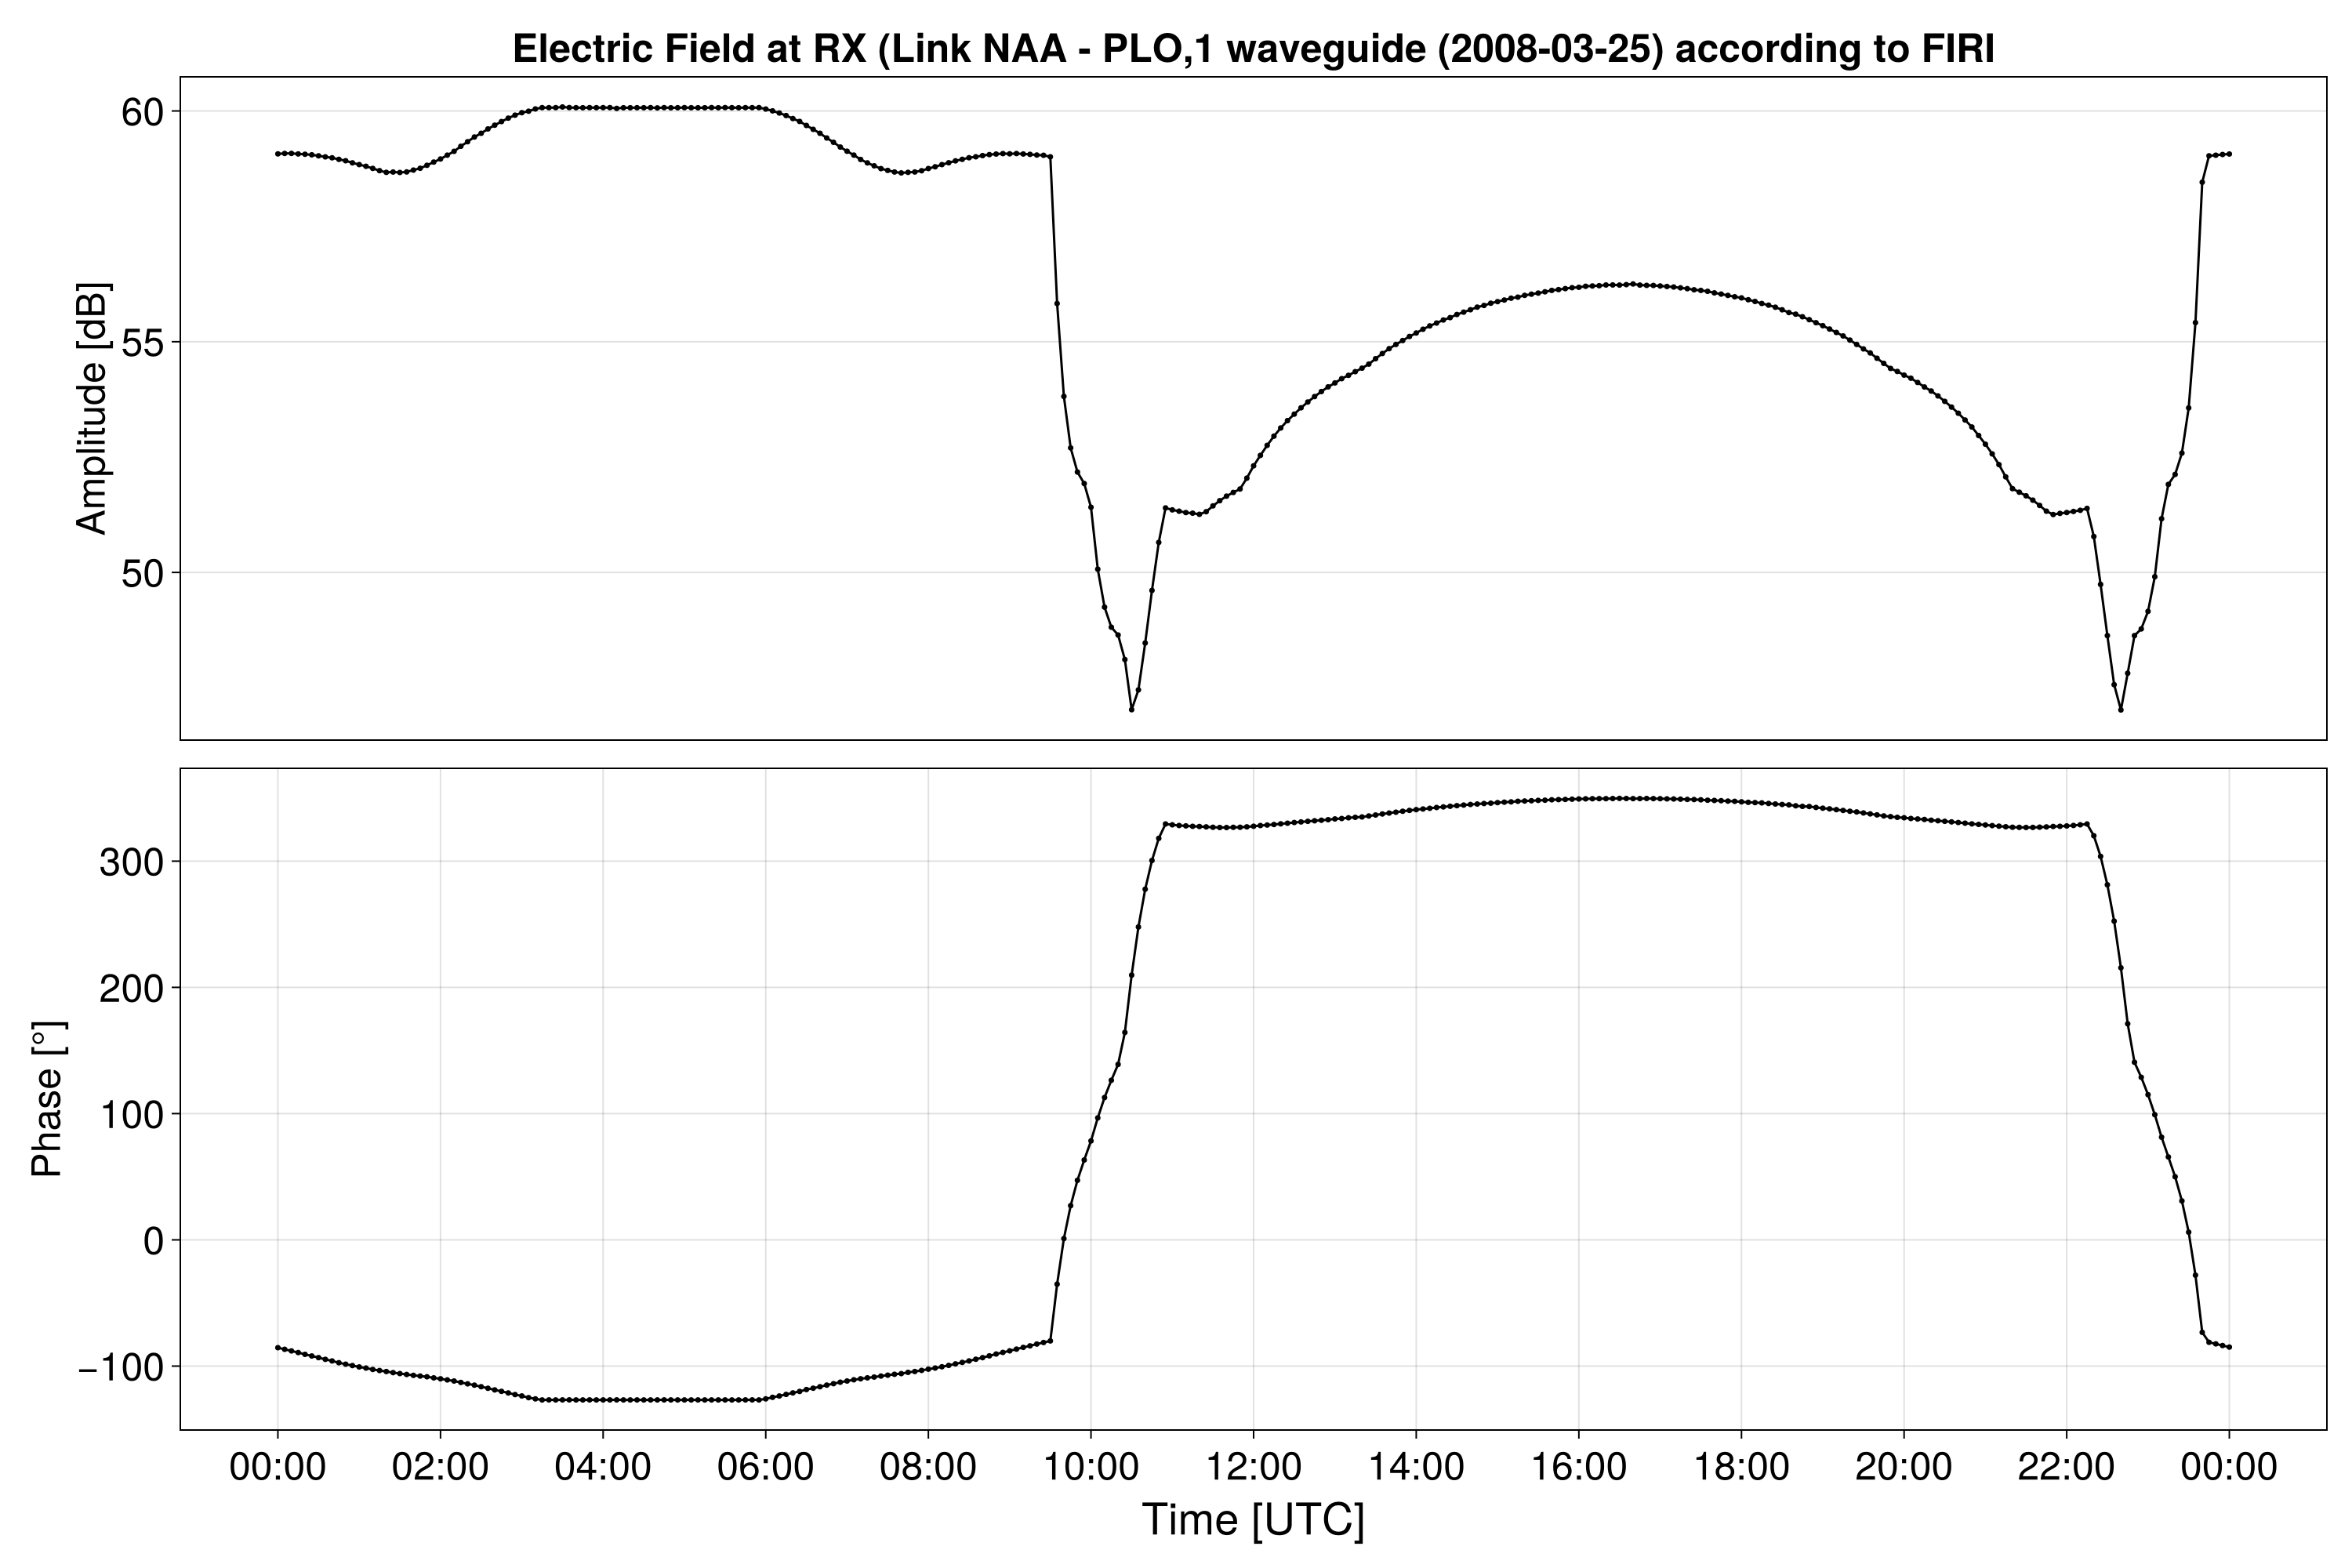

In [34]:
t0 = timerange_ref[1]
str_date2 = Dates.format(zdt_ref[1],"yyyy-mm-dd")
t_start   = DateTime(year(t0), month(t0), day(t0), 13, 0)
t_end     = DateTime(year(t0), month(t0), day(t0), 21, 0)
# convertir a tu eje numérico (horas desde t0)
x_start = (Dates.value(t_start) - Dates.value(t0)) / 3600000
x_end   = (Dates.value(t_end)   - Dates.value(t0)) / 3600000
# Convertir tiempos a diferencia en horas desde t0
time_numeric = (Dates.value.(timerange_ref) .- Dates.value(t0)) ./ 3600000  # ms -> h
# Definir posiciones de los ticks
xticksdisplay = timerange_ref[1]:Hour(2):timerange_ref[end]  # Cada hora
xticks_numeric = (Dates.value.(xticksdisplay) .- Dates.value(t0)) ./ 3600000  # Convertir a horas desde t0
xtick_labels = Dates.format.(xticksdisplay, "HH:MM")  # Formato deseado
fig = Figure(; size=(1500, 1000),fontisize=20)
title_lbl = "Electric Field at RX (Link $(tx_params2["Prefix"]) - $(rx_params["Prefix"]),1 waveguide ($str_date2) according to FIRI"
ax1 = Axis(fig[1, 1], ylabel="Amplitude [dB]", title=title_lbl, xticks = ([], []),xticklabelsize=25, yticklabelsize=25, xlabelsize=28,
                    ylabelsize=25, titlesize=25,)
scatterlines!(ax1, time_numeric, A_firi_refₜ, markersize=5,label="FIRI",color=:black)
ax2 = Axis(fig[2, 1], xlabel="Time [UTC]", ylabel="Phase [°]", xticks=(xticks_numeric, xtick_labels),xticklabelsize=25, yticklabelsize=25, xlabelsize=28,
                    ylabelsize=25, titlesize=28)
scatterlines!(ax2, time_numeric, ϕ_firi_unwrapped_deg_refₜ, markersize=5,label="FIRI",color=:black)
fig

In [42]:
using JLD2

filename_ref = "./reference-efield-firi.jld2"
jldsave(filename_ref; amp=A_firi_refₜ, phi=ϕ_firi_wrapped_refₜ, zdt=zdt_ref)


In [37]:
jldfile_ref = jldopen(filename_ref, "r")
A₂   = jldfile_ref["amp"]
ϕ₂   = jldfile_ref["phi"]
zdt₂ = jldfile_ref["zdt"]
close(jldfile_ref)

In [38]:
A₂ == A_firi_refₜ

true